# Topic 3 — K-Means vs GMM (Mall Customer Segmentation)

Both exam questions use the same dataset and almost the same steps, so:

* **Question 1** — segment customers with K-Means and GMM, compare with Silhouette + ARI.
* **Question 2** — the same pipeline, but choose the optimal K using the Elbow curve **and**
  Silhouette scores for K = 2..10 (added at the end of Question 1, cell "Step 3").

Running Question 1 top-to-bottom answers both questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

### Step 1: Load and inspect

In [2]:
df = pd.read_csv("datasets/Mall_Customers.csv")

print("Shape          :", df.shape)
print("Columns        :", list(df.columns))
print("Missing values :", df.isna().sum().sum())
print("\nGender counts:\n", df["Gender"].value_counts())
df.head()

Shape          : (200, 5)
Columns        : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Missing values : 0

Gender counts:
 Gender
Female    112
Male       88
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Step 2: EDA — feature distributions

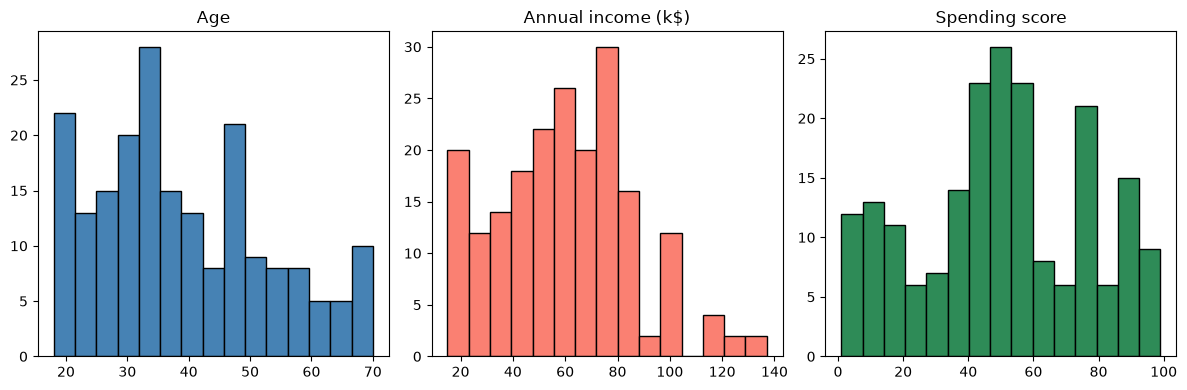

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df["Age"], bins=15, color="steelblue", edgecolor="black")
plt.title("Age")

plt.subplot(1, 3, 2)
plt.hist(df["Annual Income (k$)"], bins=15, color="salmon", edgecolor="black")
plt.title("Annual income (k$)")

plt.subplot(1, 3, 3)
plt.hist(df["Spending Score (1-100)"], bins=15, color="seagreen", edgecolor="black")
plt.title("Spending score")

plt.tight_layout()
plt.show()

### Step 3: Select features and standardize

Income and spending score are the two features normally used for mall segmentation —
they give clearly separated groups.

In [4]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = StandardScaler().fit_transform(df[features])
print("Scaled data shape:", X.shape)

Scaled data shape: (200, 2)


### Step 4: Elbow method + Silhouette score for K = 2..10

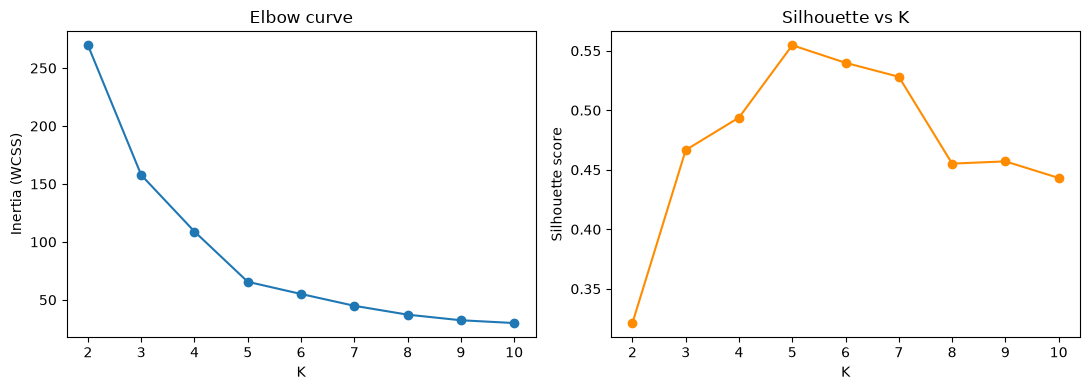

Optimal number of clusters: 5


In [5]:
def kmeans_labels(X, k):
    return KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

ks = list(range(2, 11))
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in ks]
silhouettes = [silhouette_score(X, kmeans_labels(X, k)) for k in ks]

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(ks, inertia, "o-")
plt.xlabel("K"); plt.ylabel("Inertia (WCSS)"); plt.title("Elbow curve")

plt.subplot(1, 2, 2)
plt.plot(ks, silhouettes, "o-", color="darkorange")
plt.xlabel("K"); plt.ylabel("Silhouette score"); plt.title("Silhouette vs K")

plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print("Optimal number of clusters:", best_k)

### Step 5: Apply K-Means and GMM with the same number of clusters

In [6]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
km_labels = km.labels_

gmm = GaussianMixture(n_components=best_k, random_state=42).fit(X)
gmm_labels = gmm.predict(X)

df["KMeans_Cluster"] = km_labels
df["GMM_Cluster"] = gmm_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,GMM_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,4,4


### Step 6: Visualize the clusters

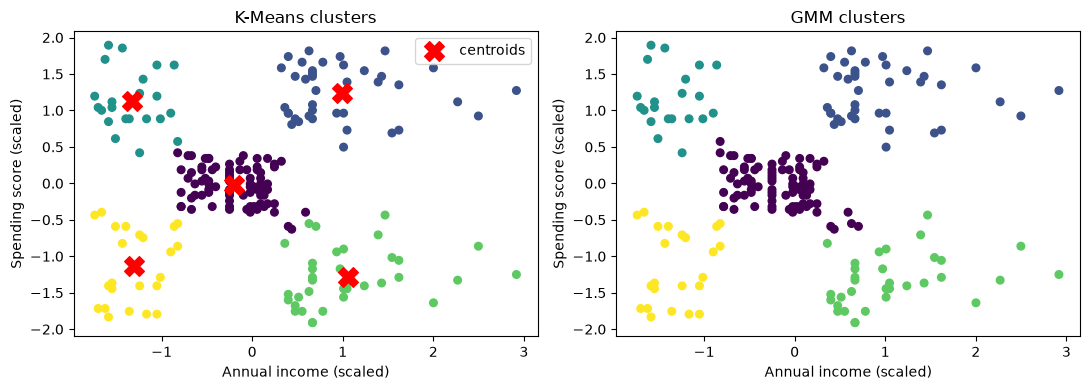

In [7]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=km_labels, cmap="viridis", s=30)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="centroids")
plt.xlabel("Annual income (scaled)"); plt.ylabel("Spending score (scaled)")
plt.title("K-Means clusters"); plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, cmap="viridis", s=30)
plt.xlabel("Annual income (scaled)"); plt.ylabel("Spending score (scaled)")
plt.title("GMM clusters")

plt.tight_layout()
plt.show()

### Step 7: Evaluate — Silhouette score and Adjusted Rand Index

There is no ground truth in this dataset, so ARI is used to measure **how similar the two
clusterings are to each other** (1.0 = identical assignments).

     Model  Silhouette
0  K-Means      0.5547
1      GMM      0.5537

Adjusted Rand Index (K-Means vs GMM): 0.9565


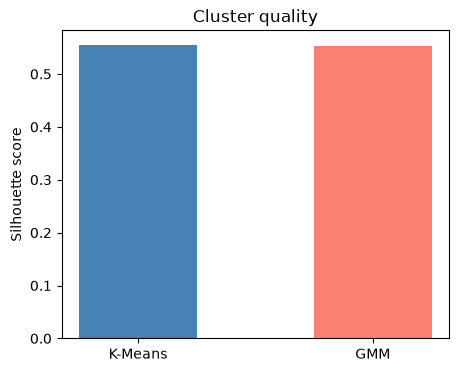

In [8]:
comparison = pd.DataFrame({
    "Model": ["K-Means", "GMM"],
    "Silhouette": [silhouette_score(X, km_labels), silhouette_score(X, gmm_labels)]
}).round(4)

print(comparison)
print("\nAdjusted Rand Index (K-Means vs GMM):",
      round(adjusted_rand_score(km_labels, gmm_labels), 4))

plt.figure(figsize=(5, 4))
plt.bar(comparison["Model"], comparison["Silhouette"], color=["steelblue", "salmon"], width=0.5)
plt.ylabel("Silhouette score"); plt.title("Cluster quality")
plt.show()

### Step 8: Describe the segments (useful business interpretation)

In [9]:
segment_summary = df.groupby("KMeans_Cluster")[["Age"] + features].mean().round(1)
segment_summary["Count"] = df["KMeans_Cluster"].value_counts().sort_index()
segment_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
KMeans_Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


**Conclusion.** The elbow curve bends at K = 5 and the silhouette score is also highest there,
so 5 segments is the right choice. K-Means and GMM produce nearly the same partition
(ARI ≈ 0.96) and nearly the same silhouette score (≈ 0.55), with K-Means marginally higher.

Say this in the exam: the clusters in this dataset are compact, round and equally sized, which is
exactly the assumption K-Means makes — so K-Means is preferable here (simpler and slightly better
separated). GMM would be the better choice if clusters were elongated/overlapping, because it fits
an elliptical Gaussian per cluster and gives soft (probability) assignments instead of hard ones.